# Scenario Analysis & Stress Testing

The objective of this notebook is to evaluate how different portfolio allocations behave under hypothetical adverse market scenarios.

In previous phases, the project analysed historical asset-level and portfolio-level risk metrics. This phase moves from historical analysis to forward-looking decision analysis by asking:

- What would happen to each portfolio under a market crash?
- Which portfolio is most vulnerable to a technology selloff?
- Which portfolio is most exposed to an interest rate shock?
- Which allocation appears more robust across different stress scenarios?

The scenarios are not predictions. They are hypothetical shocks designed to test portfolio sensitivity and robustness.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src/quant_risk_lab")

from quant_risk_lab.portfolio import DEFAULT_PORTFOLIOS
from quant_risk_lab.risk_metrics import load_returns

from quant_risk_lab.stress_testing import (
    DEFAULT_SCENARIOS,
    compute_scenario_impact_matrix,
    compute_all_scenario_contributions,
    compute_worst_scenario_by_portfolio,
    compute_best_scenario_by_portfolio,
    compute_worst_portfolio_by_scenario,
    compute_best_portfolio_by_scenario,
)

## 1. Load Asset Universe

We first load the asset return dataset in order to retrieve the asset names used throughout the project.

In [3]:
returns = load_returns()

asset_names = returns.columns.tolist()

asset_names

['AAPL', 'GLD', 'JPM', 'MSFT', 'NVDA', 'SPY', 'TLT', 'XOM']

## 2. Portfolio Weights

The portfolios analysed in this phase are the same portfolios constructed in the previous phase.

In [4]:
portfolio_weights = pd.DataFrame(DEFAULT_PORTFOLIOS).T

portfolio_weights

,AAPL,MSFT,NVDA,JPM,XOM,SPY,TLT,GLD
Equal Weight,0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125
Equity Heavy,0.150,0.150,0.150,0.100,0.100,0.250,0.050,0.050
Defensive,0.050,0.050,0.000,0.000,0.000,0.300,0.350,0.250
Growth Tech,0.250,0.250,0.250,0.000,0.000,0.150,0.050,0.050
Balanced,0.100,0.100,0.050,0.050,0.050,0.350,0.200,0.100


In [5]:
portfolio_weights.sum(axis=1)

Equal Weight    1.0
Equity Heavy    1.0
Defensive       1.0
Growth Tech     1.0
Balanced        1.0
dtype: float64

## 3. Scenario Definitions

Each scenario is defined as a set of hypothetical asset shocks.

For example, a shock of -0.25 means that the asset is assumed to fall by 25% under that scenario.

In [6]:
scenario_shocks = pd.DataFrame(DEFAULT_SCENARIOS).T

scenario_shocks

,AAPL,MSFT,NVDA,JPM,XOM,SPY,TLT,GLD
Market Crash,-0.25,-0.25,-0.35,-0.30,-0.20,-0.25,0.08,0.10
Tech Selloff,-0.25,-0.25,-0.40,-0.10,-0.05,-0.15,0.03,0.05
Interest Rate Shock,-0.12,-0.12,-0.20,0.05,0.02,-0.10,-0.18,-0.05
Energy Shock,-0.08,-0.08,-0.12,-0.05,0.20,-0.08,0.02,0.08
Inflation Shock,-0.15,-0.15,-0.25,-0.05,0.15,-0.12,-0.20,0.12
Risk-Off Scenario,-0.18,-0.18,-0.30,-0.20,-0.15,-0.18,0.10,0.12


In [7]:
scenario_shocks_percent = scenario_shocks * 100

scenario_shocks_percent

,AAPL,MSFT,NVDA,JPM,XOM,SPY,TLT,GLD
Market Crash,-25.0,-25.0,-35.0,-30.0,-20.0,-25.0,8.0,10.0
Tech Selloff,-25.0,-25.0,-40.0,-10.0,-5.0,-15.0,3.0,5.0
Interest Rate Shock,-12.0,-12.0,-20.0,5.0,2.0,-10.0,-18.0,-5.0
Energy Shock,-8.0,-8.0,-12.0,-5.0,20.0,-8.0,2.0,8.0
Inflation Shock,-15.0,-15.0,-25.0,-5.0,15.0,-12.0,-20.0,12.0
Risk-Off Scenario,-18.0,-18.0,-30.0,-20.0,-15.0,-18.0,10.0,12.0


## 4. Scenario Impact Matrix

The scenario impact matrix shows the estimated return of each portfolio under each hypothetical scenario.

The calculation is:

Portfolio Scenario Impact = sum of asset weight × asset shock

In [8]:
scenario_impact = compute_scenario_impact_matrix(
    portfolios=DEFAULT_PORTFOLIOS,
    scenarios=DEFAULT_SCENARIOS,
    asset_names=asset_names,
)

scenario_impact

,Equal Weight,Equity Heavy,Defensive,Growth Tech,Balanced
Market Crash,-0.17750,-0.2310,-0.0470,-0.2410,-0.1540
Tech Selloff,-0.14000,-0.1835,-0.0470,-0.2435,-0.1190
Interest Rate Shock,-0.08750,-0.0955,-0.1175,-0.1365,-0.1065
Energy Shock,-0.01375,-0.0420,-0.0050,-0.0770,-0.0305
Inflation Shock,-0.08125,-0.1065,-0.0910,-0.1595,-0.1075
Risk-Off Scenario,-0.12125,-0.1680,-0.0070,-0.1810,-0.0995


In [9]:
scenario_impact_percent = scenario_impact * 100

scenario_impact_percent

,Equal Weight,Equity Heavy,Defensive,Growth Tech,Balanced
Market Crash,-17.750,-23.10,-4.70,-24.10,-15.40
Tech Selloff,-14.000,-18.35,-4.70,-24.35,-11.90
Interest Rate Shock,-8.750,-9.55,-11.75,-13.65,-10.65
Energy Shock,-1.375,-4.20,-0.50,-7.70,-3.05
Inflation Shock,-8.125,-10.65,-9.10,-15.95,-10.75
Risk-Off Scenario,-12.125,-16.80,-0.70,-18.10,-9.95


In [10]:
output_path = Path("../data/processed/scenario_impact.csv")
scenario_impact.to_csv(output_path)

output_path

PosixPath('../data/processed/scenario_impact.csv')

## 5. Scenario Impact by Portfolio

This chart compares how each portfolio performs under each stress scenario.

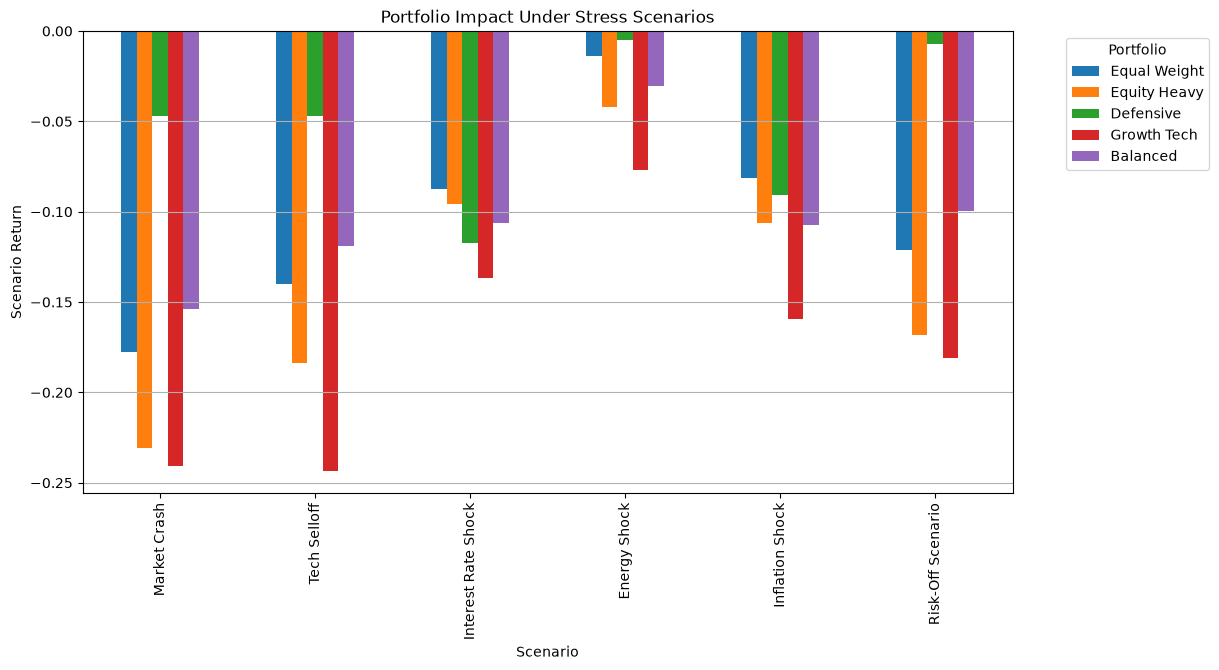

In [11]:
scenario_impact.plot(kind="bar", figsize=(12, 6))

plt.title("Portfolio Impact Under Stress Scenarios")
plt.ylabel("Scenario Return")
plt.xlabel("Scenario")
plt.grid(axis="y")
plt.legend(title="Portfolio", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 6. Scenario Impact Heatmap

The heatmap provides a compact view of portfolio vulnerability across scenarios.

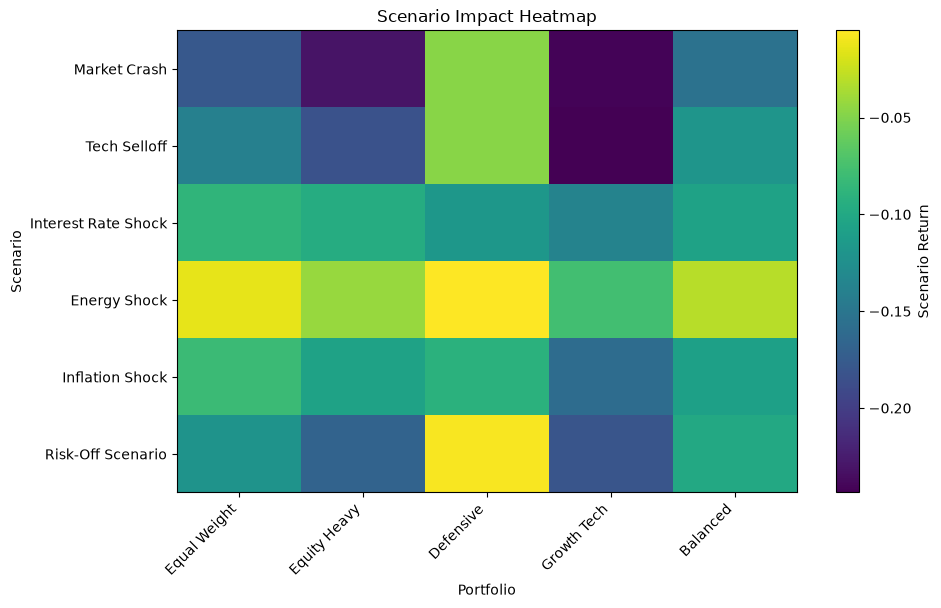

In [12]:
plt.figure(figsize=(10, 6))
plt.imshow(scenario_impact, aspect="auto")
plt.colorbar(label="Scenario Return")

plt.xticks(
    range(len(scenario_impact.columns)),
    scenario_impact.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(scenario_impact.index)),
    scenario_impact.index,
)

plt.title("Scenario Impact Heatmap")
plt.xlabel("Portfolio")
plt.ylabel("Scenario")
plt.show()

## 7. Worst Scenario by Portfolio

This table identifies the most damaging scenario for each portfolio.

In [13]:
worst_scenario_by_portfolio = compute_worst_scenario_by_portfolio(scenario_impact)

worst_scenario_by_portfolio

,Worst Scenario,Worst Scenario Impact
Equal Weight,Market Crash,-0.1775
Equity Heavy,Market Crash,-0.2310
Defensive,Interest Rate Shock,-0.1175
Growth Tech,Tech Selloff,-0.2435
Balanced,Market Crash,-0.1540


In [14]:
worst_scenario_by_portfolio_percent = worst_scenario_by_portfolio.copy()
worst_scenario_by_portfolio_percent["Worst Scenario Impact"] = (
    worst_scenario_by_portfolio_percent["Worst Scenario Impact"] * 100
)

worst_scenario_by_portfolio_percent

,Worst Scenario,Worst Scenario Impact
Equal Weight,Market Crash,-17.75
Equity Heavy,Market Crash,-23.10
Defensive,Interest Rate Shock,-11.75
Growth Tech,Tech Selloff,-24.35
Balanced,Market Crash,-15.40


## 8. Best Scenario by Portfolio

This table identifies the best scenario for each portfolio.

In [15]:
best_scenario_by_portfolio = compute_best_scenario_by_portfolio(scenario_impact)

best_scenario_by_portfolio

,Best Scenario,Best Scenario Impact
Equal Weight,Energy Shock,-0.01375
Equity Heavy,Energy Shock,-0.04200
Defensive,Energy Shock,-0.00500
Growth Tech,Energy Shock,-0.07700
Balanced,Energy Shock,-0.03050


In [16]:
best_scenario_by_portfolio_percent = best_scenario_by_portfolio.copy()
best_scenario_by_portfolio_percent["Best Scenario Impact"] = (
    best_scenario_by_portfolio_percent["Best Scenario Impact"] * 100
)

best_scenario_by_portfolio_percent

,Best Scenario,Best Scenario Impact
Equal Weight,Energy Shock,-1.375
Equity Heavy,Energy Shock,-4.200
Defensive,Energy Shock,-0.500
Growth Tech,Energy Shock,-7.700
Balanced,Energy Shock,-3.050


## 9. Worst Portfolio by Scenario

This table identifies which portfolio suffers the largest loss under each scenario.

In [17]:
worst_portfolio_by_scenario = compute_worst_portfolio_by_scenario(scenario_impact)

worst_portfolio_by_scenario

,Worst Portfolio,Worst Impact
Market Crash,Growth Tech,-0.2410
Tech Selloff,Growth Tech,-0.2435
Interest Rate Shock,Growth Tech,-0.1365
Energy Shock,Growth Tech,-0.0770
Inflation Shock,Growth Tech,-0.1595
Risk-Off Scenario,Growth Tech,-0.1810


In [18]:
worst_portfolio_by_scenario_percent = worst_portfolio_by_scenario.copy()
worst_portfolio_by_scenario_percent["Worst Impact"] = (
    worst_portfolio_by_scenario_percent["Worst Impact"] * 100
)

worst_portfolio_by_scenario_percent

,Worst Portfolio,Worst Impact
Market Crash,Growth Tech,-24.10
Tech Selloff,Growth Tech,-24.35
Interest Rate Shock,Growth Tech,-13.65
Energy Shock,Growth Tech,-7.70
Inflation Shock,Growth Tech,-15.95
Risk-Off Scenario,Growth Tech,-18.10


## 10. Best Portfolio by Scenario

This table identifies which portfolio is most resilient under each scenario.

In [19]:
best_portfolio_by_scenario = compute_best_portfolio_by_scenario(scenario_impact)

best_portfolio_by_scenario

,Best Portfolio,Best Impact
Market Crash,Defensive,-0.04700
Tech Selloff,Defensive,-0.04700
Interest Rate Shock,Equal Weight,-0.08750
Energy Shock,Defensive,-0.00500
Inflation Shock,Equal Weight,-0.08125
Risk-Off Scenario,Defensive,-0.00700


In [20]:
best_portfolio_by_scenario_percent = best_portfolio_by_scenario.copy()
best_portfolio_by_scenario_percent["Best Impact"] = (
    best_portfolio_by_scenario_percent["Best Impact"] * 100
)

best_portfolio_by_scenario_percent

,Best Portfolio,Best Impact
Market Crash,Defensive,-4.700
Tech Selloff,Defensive,-4.700
Interest Rate Shock,Equal Weight,-8.750
Energy Shock,Defensive,-0.500
Inflation Shock,Equal Weight,-8.125
Risk-Off Scenario,Defensive,-0.700


## 11. Scenario Contributions

Scenario contributions show how much each asset contributes to the total portfolio impact under a given scenario.

Contribution = asset weight × asset shock

In [21]:
scenario_contributions = compute_all_scenario_contributions(
    portfolios=DEFAULT_PORTFOLIOS,
    scenarios=DEFAULT_SCENARIOS,
    asset_names=asset_names,
)

scenario_contributions

AAPL      GLD      JPM     MSFT     NVDA  \
Scenario            Portfolio                                                   
Market Crash        Equal Weight -0.03125  0.01250 -0.03750 -0.03125 -0.04375   
                    Equity Heavy -0.03750  0.00500 -0.03000 -0.03750 -0.05250   
                    Defensive    -0.01250  0.02500 -0.00000 -0.01250 -0.00000   
                    Growth Tech  -0.06250  0.00500 -0.00000 -0.06250 -0.08750   
                    Balanced     -0.02500  0.01000 -0.01500 -0.02500 -0.01750   
Tech Selloff        Equal Weight -0.03125  0.00625 -0.01250 -0.03125 -0.05000   
                    Equity Heavy -0.03750  0.00250 -0.01000 -0.03750 -0.06000   
                    Defensive    -0.01250  0.01250 -0.00000 -0.01250 -0.00000   
                    Growth Tech  -0.06250  0.00250 -0.00000 -0.06250 -0.10000   
                    Balanced     -0.02500  0.00500 -0.00500 -0.02500 -0.02000   
Interest Rate Shock Equal Weight -0.01500 -0.00625  0.00625 -0.01500 -0.02500   
                    Equity Heavy -0.01800 -0.00250  0.00500 -0.01800 -0.03000   
                    Defensive    -0.00600 -0.01250  0.00000 -0.00600 -0.00000   
                    Growth Tech  -0.03000 -0.00250  0.00000 -0.03000 -0.05000   
                    Balanced     -0.01200 -0.00500  0.00250 -0.01200 -0.01000   
Energy Shock        Equal Weight -0.01000  0.01000 -0.00625 -0.01000 -0.01500   
                    Equity Heavy -0.01200  0.00400 -0.00500 -0.01200 -0.01800   
                    Defensive    -0.00400  0.02000 -0.00000 -0.00400 -0.00000   
                    Growth Tech  -0.02000  0.00400 -0.00000 -0.02000 -0.03000   
                    Balanced     -0.00800  0.00800 -0.00250 -0.00800 -0.00600   
Inflation Shock     Equal Weight -0.01875  0.01500 -0.00625 -0.01875 -0.03125   
                    Equity Heavy -0.02250  0.00600 -0.00500 -0.02250 -0.03750   
                    Defensive    -0.00750  0.03000 -0.00000 -0.00750 -0.00000   
                    Growth Tech  -0.03750  0.00600 -0.00000 -0.03750 -0.06250   
                    Balanced     -0.01500  0.01200 -0.00250 -0.01500 -0.01250   
Risk-Off Scenario   Equal Weight -0.02250  0.01500 -0.02500 -0.02250 -0.03750   
                    Equity Heavy -0.02700  0.00600 -0.02000 -0.02700 -0.04500   
                    Defensive    -0.00900  0.03000 -0.00000 -0.00900 -0.00000   
                    Growth Tech  -0.04500  0.00600 -0.00000 -0.04500 -0.07500   
                    Balanced     -0.01800  0.01200 -0.01000 -0.01800 -0.01500   

                                      SPY      TLT      XOM  
Scenario            Portfolio                                
Market Crash        Equal Weight -0.03125  0.01000 -0.02500  
                    Equity Heavy -0.06250  0.00400 -0.02000  
                    Defensive    -0.07500  0.02800 -0.00000  
                    Growth Tech  -0.03750  0.00400 -0.00000  
                    Balanced     -0.08750  0.01600 -0.01000  
Tech Selloff        Equal Weight -0.01875  0.00375 -0.00625  
                    Equity Heavy -0.03750  0.00150 -0.00500  
                    Defensive    -0.04500  0.01050 -0.00000  
                    Growth Tech  -0.02250  0.00150 -0.00000  
                    Balanced     -0.05250  0.00600 -0.00250  
Interest Rate Shock Equal Weight -0.01250 -0.02250  0.00250  
                    Equity Heavy -0.02500 -0.00900  0.00200  
                    Defensive    -0.03000 -0.06300  0.00000  
                    Growth Tech  -0.01500 -0.00900  0.00000  
                    Balanced     -0.03500 -0.03600  0.00100  
Energy Shock        Equal Weight -0.01000  0.00250  0.02500  
                    Equity Heavy -0.02000  0.00100  0.02000  
                    Defensive    -0.02400  0.00700  0.00000  
                    Growth Tech  -0.01200  0.00100  0.00000  
                    Balanced     -0.02800  0.00400  0.01000  
Inflation Shock     Equal Weight -0.01500 -0.02500  0.01875  
                  

In [22]:
output_path = Path("../data/processed/scenario_contributions.csv")
scenario_contributions.to_csv(output_path)

output_path

PosixPath('../data/processed/scenario_contributions.csv')

## 12. Example: Growth Tech Under Tech Selloff

This section analyses why the Growth Tech portfolio is vulnerable under a technology selloff scenario.

In [23]:
growth_tech_tech_selloff = scenario_contributions.loc[
    ("Tech Selloff", "Growth Tech")
]

growth_tech_tech_selloff.sort_values()  

NVDA   -0.1000
AAPL   -0.0625
MSFT   -0.0625
SPY    -0.0225
JPM    -0.0000
XOM    -0.0000
TLT     0.0015
GLD     0.0025
Name: (Tech Selloff, Growth Tech), dtype: float64

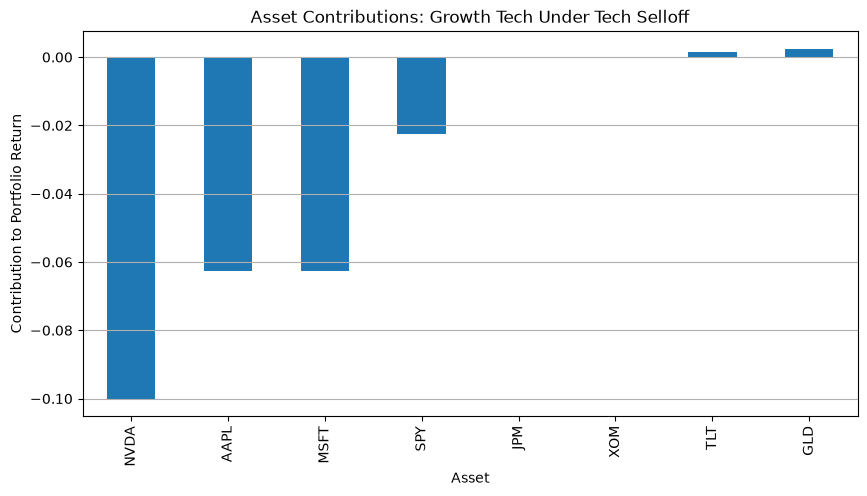

In [24]:
growth_tech_tech_selloff.sort_values().plot(kind="bar", figsize=(10, 5))

plt.title("Asset Contributions: Growth Tech Under Tech Selloff")
plt.ylabel("Contribution to Portfolio Return")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 13. Example: Defensive Portfolio Under Market Crash

This section analyses how the Defensive portfolio behaves under a broad market crash scenario.

In [25]:
defensive_market_crash = scenario_contributions.loc[
    ("Market Crash", "Defensive")
]

defensive_market_crash.sort_values()

SPY    -0.0750
AAPL   -0.0125
MSFT   -0.0125
JPM    -0.0000
NVDA   -0.0000
XOM    -0.0000
GLD     0.0250
TLT     0.0280
Name: (Market Crash, Defensive), dtype: float64

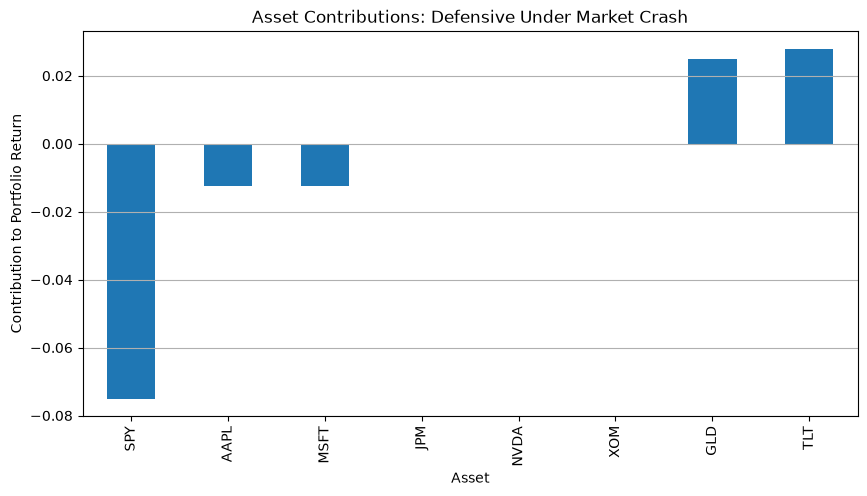

In [26]:
defensive_market_crash.sort_values().plot(kind="bar", figsize=(10, 5))

plt.title("Asset Contributions: Defensive Under Market Crash")
plt.ylabel("Contribution to Portfolio Return")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 14. Average Scenario Impact

The average scenario impact gives a simple view of how each portfolio behaves across the defined stress scenarios.

This is not an expected return because the scenarios do not have probabilities. It is only a descriptive robustness indicator.

In [27]:
average_scenario_impact = scenario_impact.mean(axis=0).sort_values(ascending=False)

average_scenario_impact

Defensive      -0.052417
Balanced       -0.102833
Equal Weight   -0.103542
Equity Heavy   -0.137750
Growth Tech    -0.173083
dtype: float64

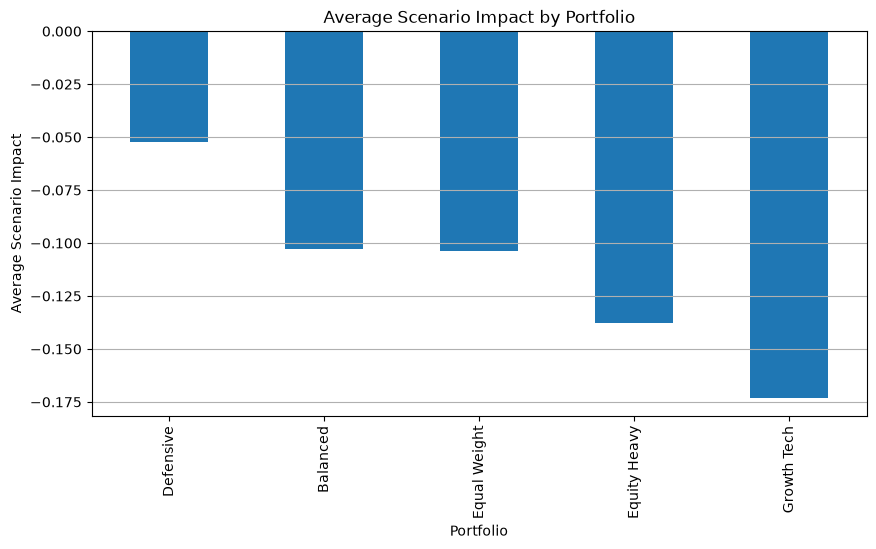

In [28]:
average_scenario_impact.plot(kind="bar", figsize=(10, 5))

plt.title("Average Scenario Impact by Portfolio")
plt.ylabel("Average Scenario Impact")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## 15. Worst-Case Scenario Impact

The worst-case scenario impact shows the largest loss each portfolio experiences across the defined stress scenarios.

In [29]:
worst_case_impact = scenario_impact.min(axis=0).sort_values()

worst_case_impact

Growth Tech    -0.2435
Equity Heavy   -0.2310
Equal Weight   -0.1775
Balanced       -0.1540
Defensive      -0.1175
dtype: float64

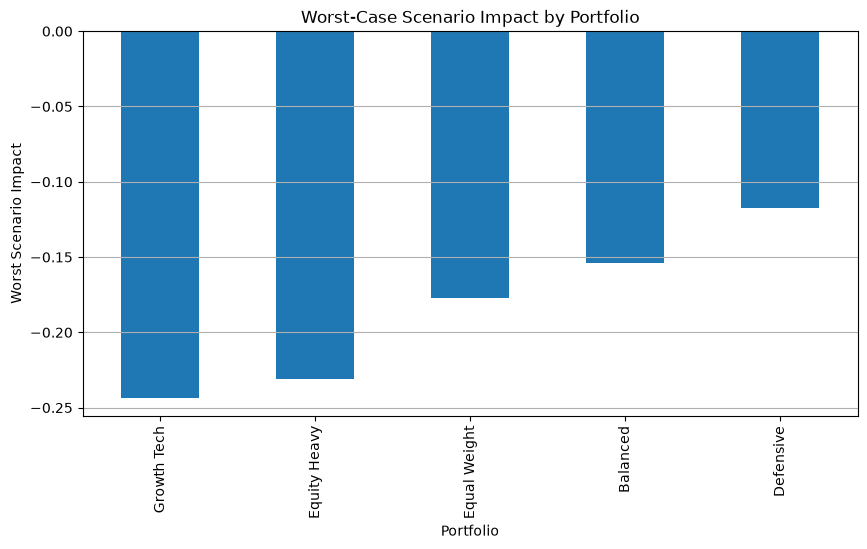

In [30]:
worst_case_impact.plot(kind="bar", figsize=(10, 5))

plt.title("Worst-Case Scenario Impact by Portfolio")
plt.ylabel("Worst Scenario Impact")
plt.xlabel("Portfolio")
plt.grid(axis="y")
plt.show()

## Key Insights

This phase extends the portfolio analysis by testing how different allocations behave under hypothetical stress scenarios.

The results show that portfolios with higher exposure to technology and equities are generally more vulnerable to market crash and technology selloff scenarios. In contrast, portfolios with larger allocations to bonds and gold may be more resilient in risk-off scenarios, depending on how the scenario is defined.

However, defensive portfolios are not risk-free. In an interest rate shock or inflation shock, long-duration bonds such as TLT may suffer significant losses.

Scenario analysis is useful because it highlights portfolio vulnerabilities that may not be obvious from historical performance metrics alone. A portfolio with strong historical CAGR or Sharpe Ratio may still be highly exposed to specific shocks.

The next step will be to extend this framework using Monte Carlo simulation, where instead of testing a small number of predefined scenarios, thousands of possible future outcomes can be simulated.